In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, average_precision_score, auc, roc_curve
import matplotlib.pyplot as plt

In [2]:
# Store results for plotting
context_labels = []
auroc_test = []
auprc_test = []

for context in ['2k', '4k', '8k']:
    if context == '2k':
        labelPath = '../../../results/PlantCAD2_tasks/exp-leaf-bin/test.tsv'
        predPath = '../../../results/PlantCAD2_tasks/exp-leaf-bin/pcv2-l24-d0768-checkpoints-lr-1e-4/predictions.csv'
    else:
        labelPath = f'../../../results/PlantCAD2_tasks/exp-leaf-bin/test_{context}.tsv'
        predPath = f'../../../results/PlantCAD2_tasks/exp-leaf-bin/pcv2-l24-d0768-{context}-checkpoints-lr-1e-4/test_{context}_predictions.tsv'
    
    labels = pd.read_csv(labelPath, sep='\t')
    predictions = pd.read_csv(predPath, sep='\t')
    
    test_true = labels['Label']
    test_preds = predictions['probability_positive']
    
    fpr, tpr, thresholds = roc_curve(test_true, test_preds)
    
    auroc = auc(fpr, tpr)
    auprc = average_precision_score(test_true, test_preds)
    print(f'Context of {context}; AUROC = {auroc:.4f}, AUPRC = {auprc:.4f}')
    
    # Store for plotting
    context_labels.append(context)
    auroc_test.append(auroc)
    auprc_test.append(auprc)

Context of 2k; AUROC = 0.8221, AUPRC = 0.9389
Context of 4k; AUROC = 0.8351, AUPRC = 0.9441
Context of 8k; AUROC = 0.8455, AUPRC = 0.9478


In [3]:
# Store results for plotting
context_labels = []
auroc_valid = []
auprc_valid = []

for context in ['2k', '4k', '8k']:
    if context == '2k':
        labelPath = '../../../results/PlantCAD2_tasks/exp-leaf-bin/valid.tsv'
        predPath = '../../../results/PlantCAD2_tasks/exp-leaf-bin/pcv2-l24-d0768-checkpoints-lr-1e-4/valid_scores.tsv'
    else:
        labelPath = f'../../../results/PlantCAD2_tasks/exp-leaf-bin/valid_{context}.tsv'
        predPath = f'../../../results/PlantCAD2_tasks/exp-leaf-bin/pcv2-l24-d0768-{context}-checkpoints-lr-1e-4/valid_{context}_predictions.tsv'
    
    labels = pd.read_csv(labelPath, sep='\t')
    predictions = pd.read_csv(predPath, sep='\t')
    
    valid_true = labels['Label']
    valid_preds = predictions['probability_positive']
    
    fpr, tpr, thresholds = roc_curve(valid_true, valid_preds)
    
    auroc = auc(fpr, tpr)
    auprc = average_precision_score(valid_true, valid_preds)
    print(f'Context of {context}; AUROC = {auroc:.4f}, AUPRC = {auprc:.4f}')
    
    # Store for plotting
    context_labels.append(context)
    auroc_valid.append(auroc)
    auprc_valid.append(auprc)

Context of 2k; AUROC = 0.8002, AUPRC = 0.8913
Context of 4k; AUROC = 0.8050, AUPRC = 0.8948
Context of 8k; AUROC = 0.8109, AUPRC = 0.8995


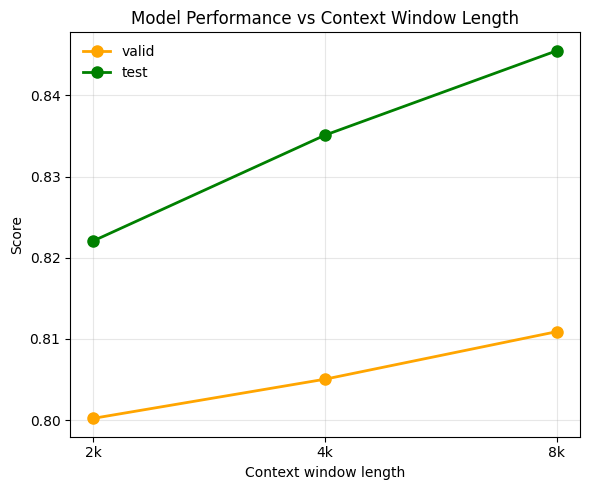

In [4]:
# Plot AUROC
plt.figure(figsize=(6, 5))
plt.plot(context_labels, auroc_valid, marker='o', color='orange', linewidth=2, markersize=8, label='valid')
plt.plot(context_labels, auroc_test, marker='o', color='green', linewidth=2, markersize=8, label='test')
plt.grid(True, alpha=0.3)
plt.xlabel('Context window length')
plt.ylabel('Score')
# plt.ylim(0.7,0.9)
plt.legend(frameon=False)
plt.title('Model Performance vs Context Window Length')
plt.tight_layout()
plt.savefig('performance_vs_context_window_exp-leaf-bin.pdf', format='pdf', bbox_inches='tight')
plt.show()